# Analyse BN des scénarios récurrents — caou

Cette analyse commence après la sélection des partitions Pareto dans le
notebook `topic_modeling_results_caou.ipynb`. Elle ne relance ni UMAP,
ni HDBSCAN, ni le resampling. Une configuration Pareto est choisie explicitement
pour chaque rôle, puis un seul réseau bayésien latent est ajusté par Structural EM.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SCENARIO_DIR = None
for base_dir in (Path.cwd(), *Path.cwd().parents):
    candidates = (
        base_dir / "text" / "recurrent_scenarios",
        base_dir,
    )
    for candidate in candidates:
        if (candidate / "scenario_pipeline.py").is_file():
            SCENARIO_DIR = candidate
            break
    if SCENARIO_DIR is not None:
        break
if SCENARIO_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver text/recurrent_scenarios/scenario_pipeline.py "
        "depuis le répertoire courant."
    )
if str(SCENARIO_DIR) not in sys.path:
    sys.path.insert(0, str(SCENARIO_DIR))

from scenario_pipeline import (
    build_frozen_bn_inputs,
    extract_latent_bn_scenarios,
    finalize_latent_bn,
    fit_latent_bn_analysis,
    load_yaml_config,
    select_dataset_config,
    resolve_config_paths,
    load_units,
    write_final_bn_outputs,
)


## 1. Configuration des partitions BN

Modifie uniquement les identifiants ci-dessous pour analyser d'autres
partitions Pareto. Il faut exactement une configuration par rôle. Ces choix
n'entraînent aucune nouvelle étape de clustering.


In [2]:
DATASET_ID = 'caou'
DISCOVERY_RUN_NAME = "theme_discovery_audit"
RUN_DIR = SCENARIO_DIR / "runs" / DISCOVERY_RUN_NAME / DATASET_ID
BN_OUTPUT_DIR = RUN_DIR / "bayesian_networks"

BN_PARTITION_SELECTIONS = {'A0': 'A0_cfg_005', 'A1': 'A1_cfg_009', 'B': 'B_cfg_016', 'C': 'C_cfg_035'}

CONFIG_PATH = SCENARIO_DIR / "config.yaml"
config = resolve_config_paths(
    select_dataset_config(load_yaml_config(CONFIG_PATH), DATASET_ID),
    CONFIG_PATH,
)
config["bayesian_networks"]["min_theme_support_count"] = 20
config["bayesian_networks"]["d_max"] = 2
config["bayesian_networks"]["alpha"] = 0.5
config["bayesian_networks"]["show_progress"] = True

print("Dataset:", DATASET_ID)
print("Partitions:", BN_PARTITION_SELECTIONS)


Dataset: caou
Partitions: {'A0': 'A0_cfg_005', 'A1': 'A1_cfg_009', 'B': 'B_cfg_016', 'C': 'C_cfg_035'}


## 2. Matrice accident × facteurs figés


In [3]:
units, _ = load_units(config)
BN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
matrix, theme_dictionary, excluded_themes, roles = build_frozen_bn_inputs(
    units,
    RUN_DIR,
    BN_PARTITION_SELECTIONS,
    config,
    BN_OUTPUT_DIR,
)
factor_columns = list(theme_dictionary["variable_name"])
print("Dimensions de la matrice :", matrix.shape)
print("Accidents :", len(matrix), "Facteurs inclus :", len(factor_columns))
display(pd.DataFrame({"role": list(roles.values())}).value_counts().rename("n_facteurs").reset_index())
display(theme_dictionary)
display(excluded_themes)


Dimensions de la matrice : (838, 50)
Accidents : 838 Facteurs inclus : 49


,role,n_facteurs
0,A0,29
1,B,8
2,A1,7
3,C,5


,variable_name,topic_id,role,topic_label,configuration_id,n_units,n_accidents,mean_membership_strength,included_in_bn
0,A0__T01,A0_000,A0,Utilisation de chariots élévateurs,A0_cfg_005,180,95,0.726829,True
2,A0__T03,A0_002,A0,Activités de dépannage,A0_cfg_005,28,28,0.993140,True
4,A0__T05,A0_004,A0,Poste de Travail d'un Technicien,A0_cfg_005,40,38,0.978124,True
5,A0__T06,A0_005,A0,Fabrication de produits plastiques,A0_cfg_005,67,67,0.839731,True
6,A0__T07,A0_006,A0,Système à pression,A0_cfg_005,27,21,0.997365,True
7,A0__T08,A0_007,A0,Contexte opérationnel flou,A0_cfg_005,115,83,0.913289,True
8,A0__T09,A0_008,A0,Conditions de travail défavorables,A0_cfg_005,173,145,0.826296,True
9,A0__T10,A0_009,A0,Travail en hauteur,A0_cfg_005,118,87,0.874853,True
10,A0__T11,A0_010,A0,Assemblage de Tissus,A0_cfg_005,54,40,0.947417,True
11,A0__T12,A0_011,A0,Travaux de Maintenance,A0_cfg_005,40,31,0.953009,True


,variable_name,topic_id,role,topic_label,configuration_id,n_units,n_accidents,mean_membership_strength,included_in_bn
1,A0__T02,A0_001,A0,Manipulation de Bobines,A0_cfg_005,32,16,0.952095,False
3,A0__T04,A0_003,A0,Visites médicales et soutien psychologique,A0_cfg_005,25,17,1.000000,False


### Visualisation de la matrice multi-hot


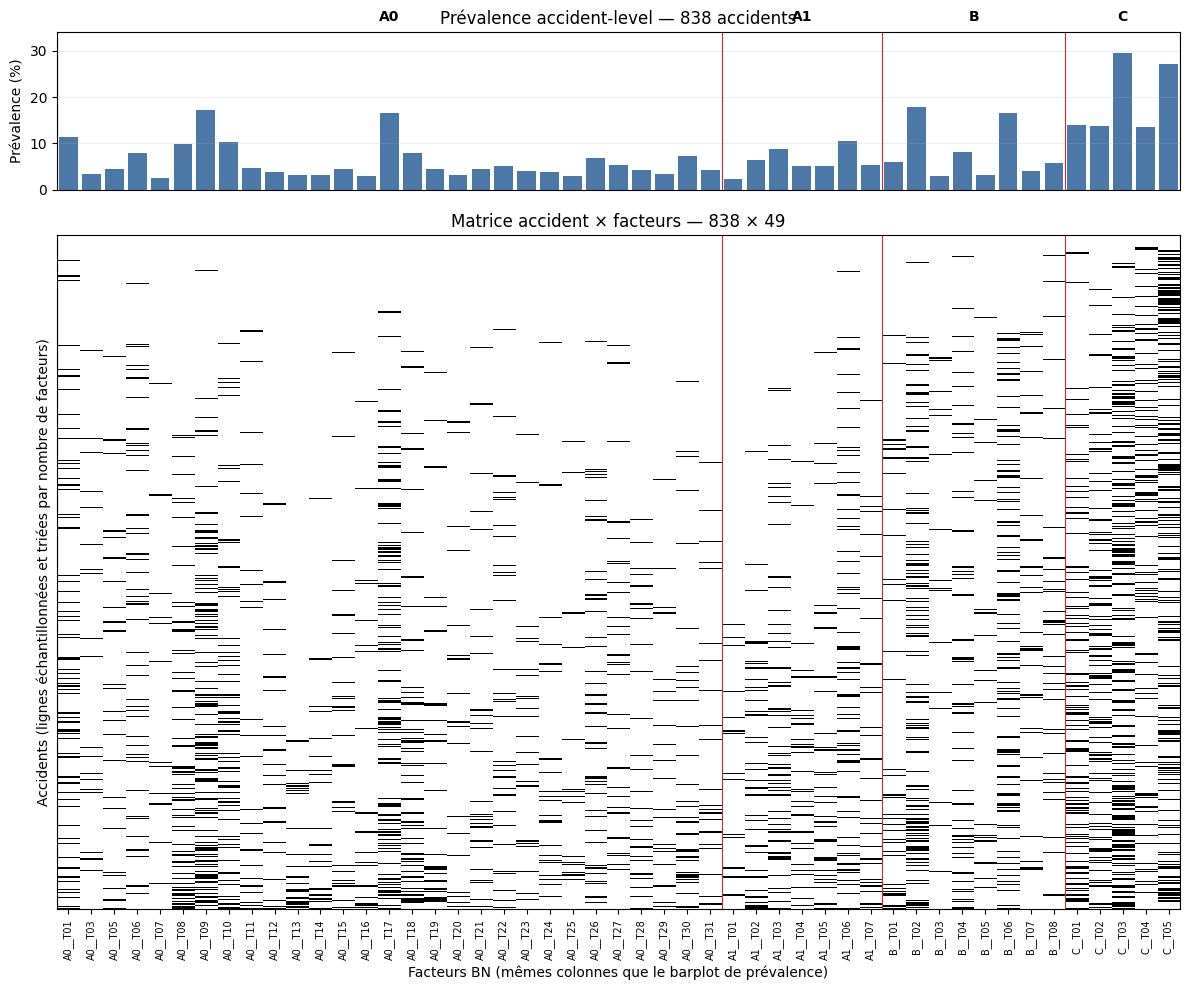

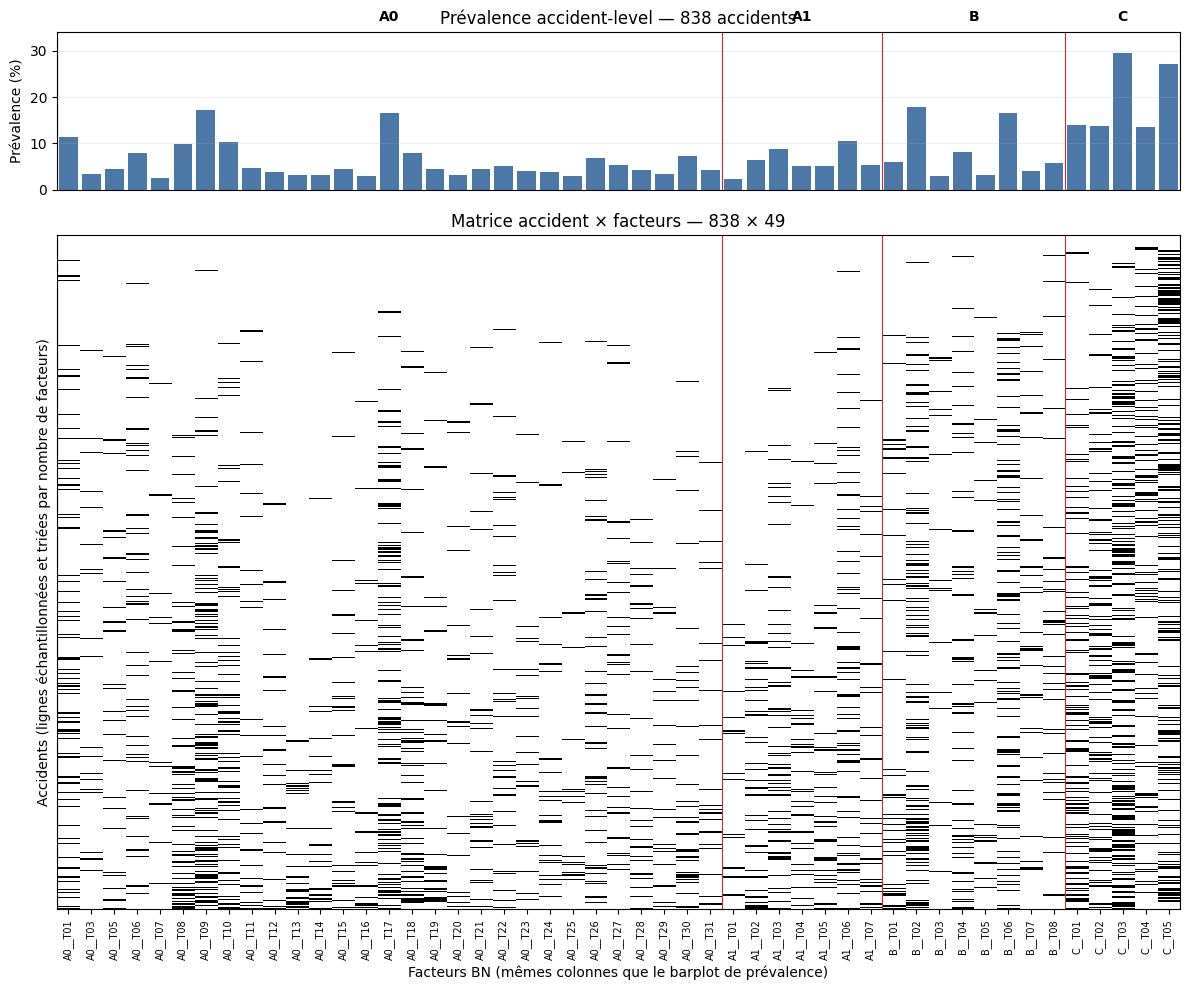

In [4]:
ordered_columns = [
    column for role in ("A0", "A1", "B", "C")
    for column in factor_columns
    if roles[column] == role
]
prevalence = matrix[ordered_columns].mean(axis=0).to_numpy(dtype=float)
heatmap_data = matrix[ordered_columns].to_numpy(dtype=np.int8)
row_order = np.argsort(heatmap_data.sum(axis=1), kind="stable")
max_heatmap_rows = 600
if len(row_order) > max_heatmap_rows:
    selected_rows = np.linspace(0, len(row_order) - 1, max_heatmap_rows, dtype=int)
    row_order = row_order[selected_rows]
heatmap_data = heatmap_data[row_order]

figure_width = max(12, len(ordered_columns) * 0.18)
fig, (prevalence_axis, heatmap_axis) = plt.subplots(
    2,
    1,
    figsize=(figure_width, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1.4, 6]},
)
factor_positions = np.arange(len(ordered_columns))
prevalence_axis.bar(factor_positions, prevalence * 100, color="#4C78A8", width=0.82)
prevalence_axis.set_ylabel("Prévalence (%)")
prevalence_axis.set_title(f"Prévalence accident-level — {matrix.shape[0]} accidents")
prevalence_axis.set_ylim(0, max(5, float(prevalence.max() * 100 * 1.15)))
prevalence_axis.grid(alpha=0.2, axis="y")
prevalence_axis.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

heatmap_axis.imshow(heatmap_data, aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)
heatmap_axis.set_xlabel("Facteurs BN (mêmes colonnes que le barplot de prévalence)")
heatmap_axis.set_ylabel("Accidents (lignes échantillonnées et triées par nombre de facteurs)")
heatmap_axis.set_title(f"Matrice accident × facteurs — {matrix.shape[0]} × {len(ordered_columns)}")
heatmap_axis.set_xticks(factor_positions)
heatmap_axis.set_xticklabels(ordered_columns, rotation=90, fontsize=7)
heatmap_axis.set_yticks([])
offset = 0
for role in ("A0", "A1", "B", "C"):
    count = sum(roles[column] == role for column in ordered_columns)
    for current_axis in (prevalence_axis, heatmap_axis):
        current_axis.axvline(offset - 0.5, color="tab:red", linewidth=0.8)
    prevalence_axis.text(offset + max(count - 1, 0) / 2, 1.05, role, transform=prevalence_axis.get_xaxis_transform(), ha="center", va="bottom", fontweight="bold")
    offset += count
for current_axis in (prevalence_axis, heatmap_axis):
    current_axis.axvline(len(ordered_columns) - 0.5, color="tab:red", linewidth=0.8)
fig.tight_layout()
fig.savefig(BN_OUTPUT_DIR / "accident_factor_matrix_heatmap.png", dpi=220, bbox_inches="tight")
display(fig)


## 3. Sélection de K par BIC


In [ ]:
selected_result, k_selection = fit_latent_bn_analysis(
    matrix,
    roles,
    config,
    BN_OUTPUT_DIR,
)
display(k_selection.sort_values(["K", "bic"]))
print("K sélectionné:", selected_result.n_states)

In [ ]:
plot_data = k_selection.copy()
plot_data["init_rank"] = plot_data.groupby("K").cumcount()
plot_data["n_initializations_K"] = plot_data.groupby("K")["K"].transform("size")
plot_data["x_plot"] = plot_data["K"] + (
    plot_data["init_rank"] - (plot_data["n_initializations_K"] - 1) / 2
) * 0.018

fig, axis = plt.subplots(figsize=(10, 6))
admissible = plot_data[plot_data["admissible"]]
inadmissible = plot_data[~plot_data["admissible"]]
axis.scatter(inadmissible["x_plot"], inadmissible["bic"], s=28, color="#BDBDBD", alpha=0.8, label="Initialisation non admissible")
axis.scatter(admissible["x_plot"], admissible["bic"], s=32, color="#4C78A8", alpha=0.75, label="Initialisation admissible")

best_per_k = plot_data[plot_data["selected_for_K"]].sort_values("K")
axis.plot(best_per_k["K"], best_per_k["bic"], color="#1F4E79", linewidth=2, marker="o", markersize=8, label="Meilleur BIC par K")

selected_k = plot_data[plot_data["selected_final"]]
axis.scatter(selected_k["K"], selected_k["bic"], s=180, marker="*", color="#D62728", edgecolor="black", linewidth=0.7, zorder=5, label=f"K⋆ = {selected_result.n_states}")
axis.set_xticks(sorted(plot_data["K"].unique()))
axis.set_xlabel("Nombre de familles latentes K")
axis.set_ylabel("BIC observé (plus faible = meilleur)")
axis.set_title("BIC selon K et les initialisations Structural EM")
axis.grid(alpha=0.25, axis="y")
axis.legend(loc="best")
fig.tight_layout()
fig.savefig(BN_OUTPUT_DIR / "bic_by_k_initializations.png", dpi=220, bbox_inches="tight")
display(fig)


## 4. Familles latentes, profils et scénarios


In [ ]:
final_result = finalize_latent_bn(selected_result, matrix, roles, config)
write_final_bn_outputs(final_result, BN_OUTPUT_DIR)
scenarios, supports, prototypes, profiles = extract_latent_bn_scenarios(
    final_result,
    matrix,
    roles,
    units,
    config,
    BN_OUTPUT_DIR,
)
analysis = {
    "matrix": matrix,
    "theme_dictionary": theme_dictionary,
    "excluded_themes": excluded_themes,
    "selection": k_selection,
    "result": final_result,
    "scenarios": scenarios,
    "supports": supports,
    "prototypes": prototypes,
    "profiles": profiles,
}
print("BN finalise :", len(final_result.nodes), "facteurs,", len(final_result.edges), "arcs")
display(analysis["profiles"].head(50))
display(analysis["scenarios"])
display(analysis["supports"])
display(analysis["prototypes"])


In [ ]:
profiles = analysis["profiles"].pivot(index="variable_name", columns="family_id", values="probability")
fig, axis = plt.subplots(figsize=(10, max(5, len(profiles) * 0.22)))
image = axis.imshow(profiles.fillna(0).to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
axis.set(yticks=np.arange(len(profiles)), yticklabels=profiles.index, xlabel="Famille latente", title="Profils factoriels P(X=1 | Z)")
fig.colorbar(image, ax=axis, label="Probabilité")
fig.tight_layout()
display(fig)


## Fichiers produits

Les résultats sont écrits dans `RUN_DIR / "bayesian_networks"`, notamment la
matrice multi-hot, les responsabilités postérieures, les profils familiaux,
les CPT finales, les arêtes apprises, les supports et les prototypes observés.
